# Model Training and Evaluation – Loss, Train/Test, Cross-Validation, Bias–Variance

**Dataset:** Bike counts in Zurich 2024–2025: daily number of bikes at 16 automatic counting stations of the city of
Zurich, with weather and calendar information (Open Data Stadt Zürich). File: `../00_Data/zurich_bike_counts_2024_2025.csv`.

**Business question:** The city wants to estimate the number of cyclists on a working day from the time of year. How
complex should such a model be so that it also works on **new** days?

**After this exercise you can ...**
- compute and compare squared and absolute loss by hand,
- explain why the training error is optimistically biased,
- use a hold-out split and k-fold cross-validation to choose model complexity,
- recognise under- and overfitting and relate them to bias and variance.

## Concept

The concepts behind this exercise (formulas and worked examples) are
explained in the notebook [model_training_evaluation_concept.ipynb](model_training_evaluation_concept.ipynb). Read it before you start.

## Libraries and settings

In [1]:
# Libraries
import os
import platform
import warnings
from datetime import datetime
from platform import python_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import root_mean_squared_error

# Ignore warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

/workspaces/python_machine_learning_basics/01_Model_Training_Evaluation


## Exercise 1: Loss functions by hand

*Time: about 15 minutes. Use the notebook cell below as your calculator: type the formulas with the numbers in
Python (e.g. `(3 + 5) / 2` or `0.4 ** 2`) – no paper needed.*

Two models predict the number of bikes at a counting station on five days:

| day | observed $y$ | model A $\hat y$ | model B $\hat y$ |
|---|---|---|---|
| 1 | 1200 | 1500 | 1250 |
| 2 | 2500 | 2300 | 2550 |
| 3 | 3100 | 3300 | 3050 |
| 4 | 4000 | 3700 | 4050 |
| 5 | 4600 | 4500 | 3800 |

a) Compute the residuals $y - \hat y$, the **MSE** (mean of the squared residuals), the **RMSE** (square root of the
MSE) and the **MAE** (mean of the absolute residuals) of model A. Hints: `np.mean()`, `np.sqrt()`, `np.abs()`.

b) Do the same for model B.

c) Which model is better according to RMSE, and which according to MAE? Why do the two measures disagree?

In [2]:
# Exercise 1: observed values and the predictions of the two models
y = np.array([1200, 2500, 3100, 4000, 4600])
y_hat_a = np.array([1500, 2300, 3300, 3700, 4500])
y_hat_b = np.array([1250, 2550, 3050, 4050, 3800])

# a) Model A: residuals, MSE, RMSE and MAE
res_a = y - y_hat_a
mse_a = np.mean(res_a**2)
rmse_a = np.sqrt(mse_a)
mae_a = np.mean(np.abs(res_a))
print(
    'Model A:',
    res_a,
    ' MSE =',
    mse_a,
    ' RMSE =',
    round(rmse_a, 1),
    ' MAE =',
    mae_a,
)

# b) Model B: the same steps
res_b = y - y_hat_b
mse_b = np.mean(res_b**2)
rmse_b = np.sqrt(mse_b)
mae_b = np.mean(np.abs(res_b))
print(
    'Model B:',
    res_b,
    ' MSE =',
    mse_b,
    ' RMSE =',
    round(rmse_b, 1),
    ' MAE =',
    mae_b,
)

Model A: [-300  200 -200  300  100]  MSE = 54000.0  RMSE = 232.4  MAE = 220.0
Model B: [-50 -50  50 -50 800]  MSE = 130000.0  RMSE = 360.6  MAE = 200.0


**Solution:**

Model A: residuals −300, 200, −200, 300, 100 → MSE = 270'000/5 = 54'000, **RMSE ≈ 232.4**, **MAE = 220**.
Model B: residuals −50, −50, 50, −50, 800 → MSE = 650'000/5 = 130'000, **RMSE ≈ 360.6**, **MAE = 200**.

According to **RMSE model A** is better, according to **MAE model B** is better. Model B is almost perfect on four days
but makes one large error (800). Squared loss weighs this single error heavily (800² = 640'000), absolute loss only
linearly. Which loss to use depends on the costs of large errors: if one big mistake is very costly (e.g. far too few
bike parking spaces at an event), squared loss is the better choice.

## Exercise 2: Import and explore the bike counts

a) Import the bike counts. Keep only **working days** (`weekend == 0` and `holiday == 0`) – otherwise the large
difference between working days and weekends dominates everything. Create the column `day_of_year`
(1 = 1 January, …, 366 = 31 December) from the column `date`.

b) Create a scatter plot of `bikes_total` (sum of all 16 counting stations) against `day_of_year`. Is the relationship
linear?

(674, 29)
(461, 30)
         date  day_of_year  bikes_total
2  2024-01-03            3        14210
3  2024-01-04            4        15750
4  2024-01-05            5        13254
7  2024-01-08            8        14432
8  2024-01-09            9        17655


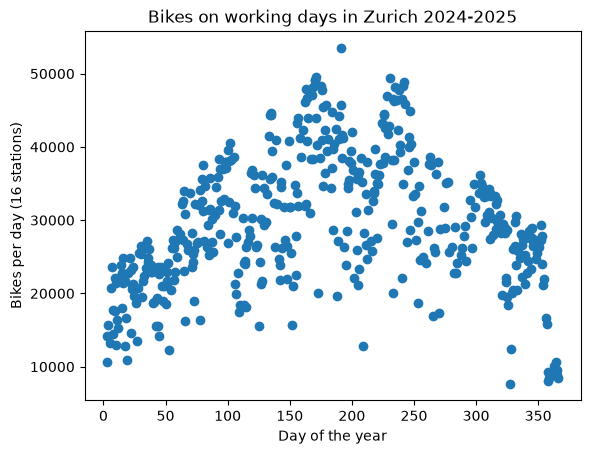

In [3]:
# a) Import the data as bikes and print its shape
bikes = pd.read_csv('../00_Data/zurich_bike_counts_2024_2025.csv', sep=',')
print(bikes.shape)

# Keep working days only (copy: a new table, not a view of bikes)
df = bikes[(bikes['weekend'] == 0) & (bikes['holiday'] == 0)].copy()

# Day of the year (1 = 1 January, ..., 366 = 31 December)
df['day_of_year'] = pd.to_datetime(df['date']).dt.dayofyear
print(df.shape)
print(df[['date', 'day_of_year', 'bikes_total']].head())

# b) Scatter plot bikes_total vs. day_of_year
plt.scatter(df['day_of_year'], df['bikes_total'])
plt.xlabel('Day of the year')
plt.ylabel('Bikes per day (16 stations)')
plt.title('Bikes on working days in Zurich 2024-2025')
plt.show()

**Solution:**

The relationship is clearly **not linear**: few bikes in winter (January, December), a strong increase in spring, high
values from May to September with a dip during the summer school holidays (mid-July to mid-August), and a decrease in
autumn. A straight line cannot capture this seasonal curve (bias); a curved model (e.g. a polynomial) should fit better.
On days with the same date the numbers still vary a lot (rain, temperature) – this is noise from the point of view of a
model that only knows the date.

## Exercise 3: Hold-out split and polynomial models

We describe the number of bikes as a polynomial of the day of the year

$$\hat y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_d x^d .$$

This is still a *linear* regression (linear in the parameters $\beta$). The **degree $d$** controls the model complexity.
The helper function `make_poly_model(degree)` below builds such a model (the features are standardised for numerical
stability).

a) Split the table `df` into a training set `train` (80 %) and a test set `test` (20 %) with
`random_state=42`.

b) Fit a polynomial of degree 1 (= simple linear regression) on the training set and compute the RMSE on the training
and on the test set.

In [4]:
# Function: builds a model with x, x², ..., x^degree and a linear regression
def make_poly_model(degree):
    """Polynomial regression model of the given degree."""
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )

In [5]:
# Exercise 3 a) Split the table into training and test days (80/20)
train, test = train_test_split(df, test_size=0.20, random_state=42)
print('Training days:', len(train), ' Test days:', len(test))

# Feature (day of the year) and target (bikes per day)
X_train = train[['day_of_year']]
y_train = train['bikes_total']
X_test = test[['day_of_year']]
y_test = test['bikes_total']

# b) Fit a polynomial of degree 1 and compute the train and test RMSE
model_1 = make_poly_model(1)
model_1.fit(X_train, y_train)

# Train and test RMSE
rmse_train = root_mean_squared_error(y_train, model_1.predict(X_train))
rmse_test = root_mean_squared_error(y_test, model_1.predict(X_test))
print('Train RMSE:', round(rmse_train))
print('Test RMSE:', round(rmse_test))

Training days: 368  Test days: 93
Train RMSE: 9055
Test RMSE: 8555


## Exercise 4: Under- and overfitting with a small training sample

Overfitting is most visible when there are only few training examples. Imagine the city had counted on only **30 days**.

a) Draw a random sample of 30 days from the training set (`train.sample(30, random_state=13)`).

b) For each degree $d = 1, 2, \dots, 15$ fit `make_poly_model(d)` on the 30 days and compute the RMSE on these 30
training days and on the (full) test set. Plot both RMSE curves against the degree (use a logarithmic y-axis).

c) Plot the fitted curves for the degrees 1, 3 and 12 together with the 30 training days.

d) Which degree underfits, which overfits, which fits well? Why does the training error keep decreasing?

    train RMSE  test RMSE
1       8370.0     9554.0
2       7319.0     7060.0
3       7318.0     7061.0
4       7157.0     8064.0
5       7156.0     8086.0
6       7012.0     8685.0
7       6996.0     9576.0
8       6835.0    12991.0
9       6778.0    17788.0
10      6728.0    23694.0
11      6691.0    30206.0
12      6640.0    51990.0
13      6658.0    51763.0
14      6668.0    44625.0
15      6658.0    29657.0


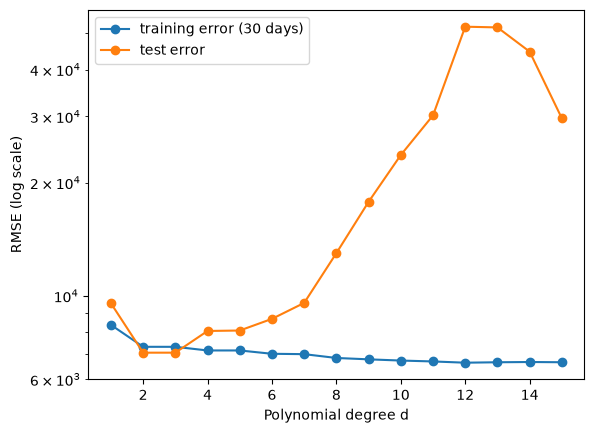

In [6]:
# a) Sample of 30 training days
small = train.sample(30, random_state=13)
X_small = small[['day_of_year']]
y_small = small['bikes_total']

# b) Train and test RMSE for degree 1..15
degrees = range(1, 16)
rmse_train = []
rmse_test = []
for d in degrees:
    model = make_poly_model(d)
    model.fit(X_small, y_small)
    rmse_train.append(root_mean_squared_error(y_small, model.predict(X_small)))
    rmse_test.append(root_mean_squared_error(y_test, model.predict(X_test)))

# Table of the train and test RMSE (one row per degree)
results = pd.DataFrame(
    {'train RMSE': rmse_train, 'test RMSE': rmse_test}, index=degrees
)
print(results.round(0))

# Figure showing the training and test error by polynomial degree
plt.plot(degrees, rmse_train, marker='o', label='training error (30 days)')
plt.plot(degrees, rmse_test, marker='o', label='test error')
plt.yscale('log')
plt.xlabel('Polynomial degree d')
plt.ylabel('RMSE (log scale)')
plt.legend()
plt.show()

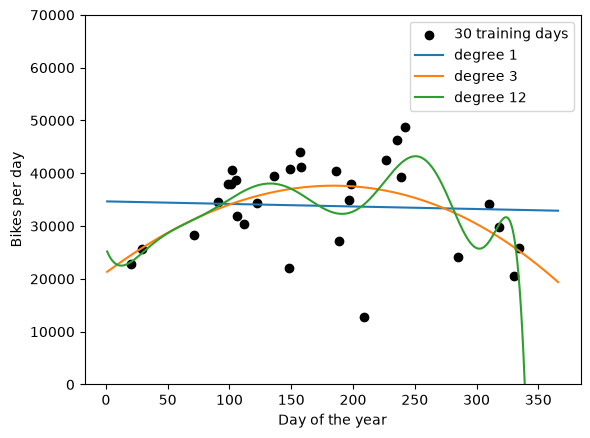

In [7]:
# c) All days of the year (for smooth curves)
x_grid = pd.DataFrame({'day_of_year': np.arange(1, 367)})

# Figure showing the 30 training days and the fitted curves
plt.scatter(X_small, y_small, color='black', label='30 training days')
for d in [1, 3, 12]:
    model = make_poly_model(d)
    model.fit(X_small, y_small)
    plt.plot(x_grid, model.predict(x_grid), label='degree ' + str(d))
plt.ylim(0, 70000)
plt.xlabel('Day of the year')
plt.ylabel('Bikes per day')
plt.legend()
plt.show()

**Solution:**

- **Degree 1 underfits**: the straight line cannot follow the seasonal curve – it has the highest error on the training
  *and* on the test data among the simple models (test RMSE ≈ 9'550; bias).
- **Degree 2–3 fit well**: they capture the seasonal curve and have the lowest test error (≈ 7'060).
- **High degrees overfit**: the curve wiggles through the 30 training days, the training error keeps decreasing, but the
  test error grows strongly – up to ≈ 52'000 for degree 12, i.e. more than 7 times the error of degree 2. The curve
  shoots up or down between and beyond the training days.

The training error can (up to numerical rounding) only decrease with the degree, because a polynomial of degree $d+1$
contains the polynomial of degree $d$ as a special case ($\beta_{d+1}=0$). The training error is therefore an
*optimistically biased* estimate of the error on new data.

## Exercise 5: Choose the degree with 5-fold cross-validation

In practice we must not look at the test set to choose the degree. Instead we use k-fold cross-validation **on the
training data only**.

a) For $d = 1, \dots, 10$ compute the 5-fold CV RMSE on the **30 training days**
(use `cross_val_score(..., scoring='neg_root_mean_squared_error', cv=KFold(5, shuffle=True, random_state=42))`;
note the minus sign). Which degree does CV select?

b) Repeat a) with the **full training set**. Which degree is selected now and how large is the difference between
degree 3 and degree 10?

c) Fit the selected model on the full training set and evaluate it **once** on the test set.

d) Why does overfitting become much less severe with more data?

    CV (30 days)  CV (all days)
1         8837.0         9107.0
2         7283.0         6864.0
3         8065.0         6849.0
4         9749.0         6858.0
5        16940.0         6883.0
6        12709.0         6864.0
7        50041.0         6822.0
8        46248.0         6821.0
9        41167.0         6824.0
10      161892.0         6846.0


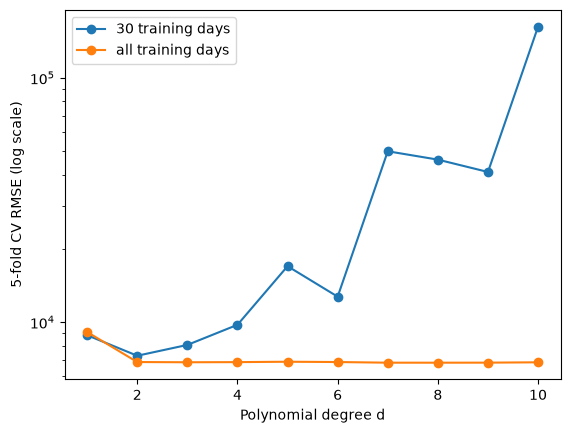

In [8]:
# Exercise 5: 5-fold cross-validation (on the training data only)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# a) and b) CV RMSE by degree for 30 days and for all training days
degrees_cv = range(1, 11)
cv_small = []
cv_full = []
for d in degrees_cv:
    scores = cross_val_score(
        make_poly_model(d),
        X_small,
        y_small,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    cv_small.append(-scores.mean())  # scikit-learn returns negative RMSE
    scores = cross_val_score(
        make_poly_model(d),
        X_train,
        y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
    )
    cv_full.append(-scores.mean())

# Table of the CV RMSE (one row per degree)
results_cv = pd.DataFrame(
    {'CV (30 days)': cv_small, 'CV (all days)': cv_full}, index=degrees_cv
)
print(results_cv.round(0))

# Figure showing the CV RMSE by degree for both training sets
plt.plot(degrees_cv, cv_small, marker='o', label='30 training days')
plt.plot(degrees_cv, cv_full, marker='o', label='all training days')
plt.yscale('log')
plt.xlabel('Polynomial degree d')
plt.ylabel('5-fold CV RMSE (log scale)')
plt.legend()
plt.show()

In [9]:
# c) Fit the selected model on the full training set,
#    evaluate once on the test set

# Degree with the smallest CV RMSE on all training days
best_degree = degrees_cv[np.argmin(cv_full)]
print('Selected degree:', best_degree)

# Fit it on all training days and evaluate it once on the test set
final_model = make_poly_model(best_degree)
final_model.fit(X_train, y_train)
rmse_final = root_mean_squared_error(y_test, final_model.predict(X_test))
print('Test RMSE:', round(rmse_final))

Selected degree: 8
Test RMSE: 6401


**Solution:**

a) With only 30 days, CV selects **degree 2** – the same degree that is best on the test set – and the CV error
explodes for high degrees (≈ 162'000 for degree 10). CV detects overfitting **without** using the test set.

b) With the full training set (368 days) the CV curve is almost flat from degree 2 on (≈ 6'820–6'880). CV formally
selects degree 8, but the difference to degree 2 or 3 is below 1 % – in such a case one usually prefers the
**simpler** model. With many observations, the extra parameters of a flexible model are pinned down by the data – the
**variance** of the fit shrinks. Overfitting is always a question of model complexity *relative to the amount of data*.

c) The selected model reaches a test RMSE of about 6'400 bikes per day.

d) The remaining error of more than 6'000 bikes per day is mostly **noise from the perspective of this model**
(weather, bridge days, …). It can only be reduced by adding further features (temperature, rain, school holidays), not by
a more complex function of the date.

## Exercise 6: Visualise bias and variance

Bias and variance describe what happens if we **repeat** the whole training on *other* samples of the same size.

a) Draw 50 different random samples of 30 days from the training set (`random_state=0, 1, ..., 49`). For each sample
fit a polynomial of degree 1, 3 and 12. Plot the 50 fitted curves per degree in three subplots
(use `ylim(0, 70000)`).

b) For each degree, compute the mean and the standard deviation of the 50 predictions for **day 180** (end of June).
What do you observe? Relate your observations to bias and variance.

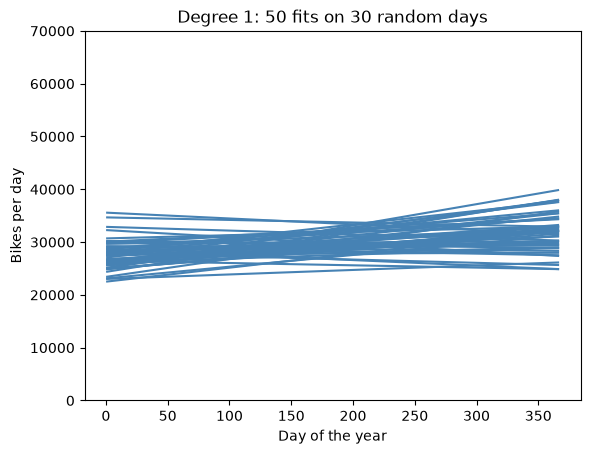

Day 180: mean = 29762   standard deviation = 1987


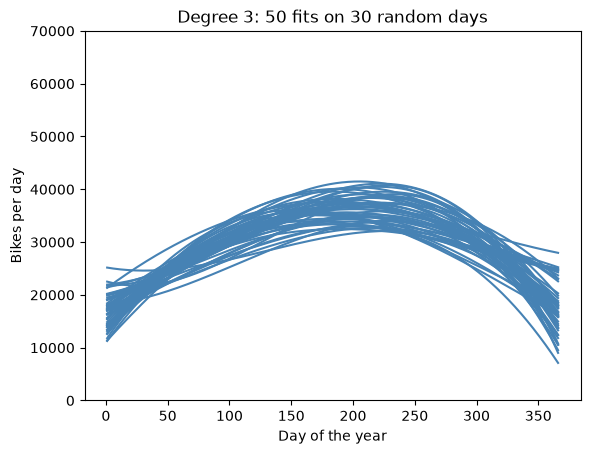

Day 180: mean = 36011   standard deviation = 2263


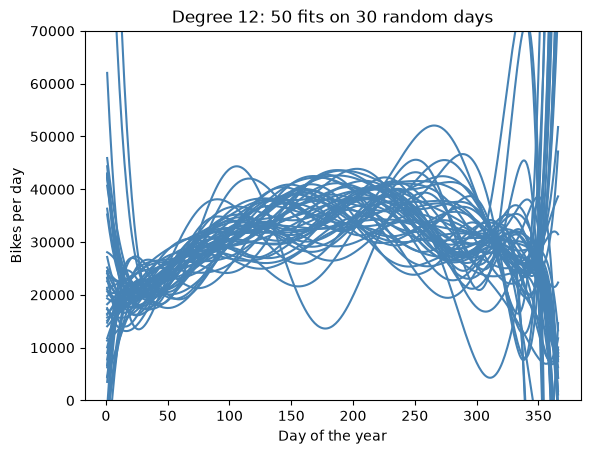

Day 180: mean = 35369   standard deviation = 5252


In [10]:
# Exercise 6: all days of the year and day 180 (end of June)
x_grid = pd.DataFrame({'day_of_year': np.arange(1, 367)})
day_180 = pd.DataFrame({'day_of_year': [180]})

# a) and b) For each degree: 50 fits on random samples of 30 days
for d in [1, 3, 12]:
    pred_180 = []
    for seed in range(50):
        sample = train.sample(30, random_state=seed)
        model = make_poly_model(d)
        model.fit(sample[['day_of_year']], sample['bikes_total'])
        plt.plot(x_grid, model.predict(x_grid), color='steelblue')
        pred_180.append(model.predict(day_180)[0])

    # Figure showing the 50 fitted curves of this degree
    plt.ylim(0, 70000)
    plt.title('Degree ' + str(d) + ': 50 fits on 30 random days')
    plt.xlabel('Day of the year')
    plt.ylabel('Bikes per day')
    plt.show()

    # Mean and standard deviation of the 50 predictions for day 180
    print(
        'Day 180: mean =',
        round(np.mean(pred_180)),
        '  standard deviation =',
        round(np.std(pred_180)),
    )

**Solution:**

- **Degree 1:** the 50 lines are similar to each other (lowest standard deviation for day 180, ≈ 2'000), but they all
  miss the seasonal curve in the same way: they systematically underestimate the bikes in early summer (mean prediction
  ≈ 29'800 vs. ≈ 36'000 for degree 3) and overestimate them in winter → high **bias**.
- **Degree 3:** the curves follow the seasonal shape and still vary only moderately – a good compromise.
- **Degree 12:** the curves differ wildly from sample to sample, especially at the beginning and the end of the year
  (high **variance**). Even for day 180, in the middle of the data, the standard deviation of the predictions
  (≈ 5'300) is more than twice as large as for degree 3.

This is exactly the bias–variance trade-off: a simple model is *stable but systematically wrong*, a very flexible model
is *right on average but unstable*. The best test error is achieved in between.

## Exercise 7: More covariates instead of a more complex curve

Exercise 5 showed that a higher polynomial degree does not reduce the error much below about 6'400 bikes per day. The
remaining error is "noise" only from the point of view of a model that knows nothing but the date. Weather and holidays
explain part of it.

a) Fit a linear regression with a polynomial of degree 3 in `day_of_year` **plus** the covariates `temp_mean`,
`rain_duration_min`, `solar_radiation` and `school_holiday` (the code for the features is given).
Use `make_pipeline(StandardScaler(), LinearRegression())`.

b) Compare its 5-fold CV RMSE and test RMSE with the polynomial of degree 3 without covariates.

c) What does this tell you about bias, variance and the noise term?

In [11]:
# Exercise 7 a) Square and cube of the day of the year (degree 3)
train['day_of_year_2'] = train['day_of_year'] ** 2
train['day_of_year_3'] = train['day_of_year'] ** 3
test['day_of_year_2'] = test['day_of_year'] ** 2
test['day_of_year_3'] = test['day_of_year'] ** 3

# Features: polynomial of degree 3 plus weather and holidays
features = [
    'day_of_year',
    'day_of_year_2',
    'day_of_year_3',
    'temp_mean',
    'rain_duration_min',
    'solar_radiation',
    'school_holiday',
]

# Fit the linear regression with all features
# (standardised, as in make_poly_model, because the cube of the day
# number is very large)
model_cov = make_pipeline(StandardScaler(), LinearRegression())
model_cov.fit(train[features], y_train)

# b) CV RMSE and test RMSE; compare with degree 3 without covariates
scores = cross_val_score(
    model_cov,
    train[features],
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error',
)
rmse_cov = root_mean_squared_error(y_test, model_cov.predict(test[features]))
print(
    'Date + covariates: CV RMSE =',
    round(-scores.mean()),
    '  test RMSE =',
    round(rmse_cov),
)

# Comparison: degree 3 without covariates (CV RMSE from Exercise 5)
model_3 = make_poly_model(3)
model_3.fit(X_train, y_train)
rmse_3 = root_mean_squared_error(y_test, model_3.predict(X_test))
print(
    'Date only:         CV RMSE =',
    round(cv_full[2]),
    '  test RMSE =',
    round(rmse_3),
)

# Coefficients per standard deviation of each feature
# (model_cov[-1] = last step of the pipeline = the linear regression)
print(pd.Series(model_cov[-1].coef_, index=features).round(0))

Date + covariates: CV RMSE = 3577   test RMSE = 3064
Date only:         CV RMSE = 6849   test RMSE = 6455
day_of_year         -1028.0
day_of_year_2        9996.0
day_of_year_3       -8338.0
temp_mean            3082.0
rain_duration_min   -2920.0
solar_radiation      3742.0
school_holiday      -2924.0
dtype: float64


**Solution:**

b)
| model | CV RMSE | test RMSE |
|---|---|---|
| degree 3 (date only) | ≈ 6'850 | ≈ 6'450 |
| degree 3 + weather + holidays | ≈ 3'580 | ≈ 3'060 |

With four additional covariates the error is roughly **halved** – a much larger gain than any change of the polynomial
degree in Exercises 4 and 5. The coefficients (per standard deviation of each covariate) show the expected signs: warm
and sunny days increase, rain and school holidays decrease the number of bikes.

c) The "noise" $\sigma^2$ in the bias–variance decomposition is always noise **relative to the available features**.
A more flexible function of the date can only trade bias against variance; it cannot explain why a rainy Tuesday has fewer
cyclists than a sunny one. New, informative covariates reduce the part of the error that looked like irreducible noise.
They add only a few parameters, so the variance hardly increases (CV and test errors are similar).

## Exercise 8: Reflection

a) A colleague chooses the polynomial degree by trying all degrees and picking the one with the smallest **test** error.
What is the problem?

b) Why is k-fold cross-validation usually preferred over a single validation split when the data set is small?

c) Name two ways to reduce the variance of a model and one way to reduce its bias.

**Solution:**

a) The test set is then used for model selection; the reported test error is the *minimum* over many models and
therefore optimistically biased. The test set no longer measures performance on truly unseen data. Hyperparameters must
be chosen with a validation set or cross-validation on the training data.

b) With a single split, the result depends strongly on which few observations end up in the validation set. k-fold CV
uses every observation once for validation and averages over $k$ estimates, which gives a more stable estimate and uses
the data more efficiently.

c) Lower variance: collect more training data, use a simpler model (lower degree), regularisation/pruning, or averaging
many models (bagging, random forest). Lower bias: use a more flexible model (e.g. higher degree, trees) or add
informative features (e.g. temperature, rain, school holidays).

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [12]:
# Show operating system, date/time and Python version
print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-02 14:40:49
Python Version: 3.11.16
-----------------------------------
